In [1]:
!hostname

cn076.delta.ncsa.illinois.edu


In [36]:
import scanpy as sc
from pathlib import Path
import numpy as np
import pandas as pd
import anndata as ad
ad.settings.allow_write_nullable_strings = True
import matplotlib.pyplot as plt
import seaborn as sns
import gseapy as gp
import decoupler

In [3]:
import os
os.chdir('/projects/bgdb/asachan/bioinfo_analysis/human_SKM_multimodal_analysis/py_scripts')  # directory containing utils.py
import sys
import logging
import warnings

export_dir = "/work/hdd/bgdb/asachan/datasets_proj/SKM_ageing_human"

In [4]:
from utils import *

In [5]:
adata_rna = '/work/hdd/bgdb/asachan/datasets_proj/SKM_ageing_human/rna_objects/rna_female_type2.h5ad'
adata_atac = '/work/hdd/bgdb/asachan/datasets_proj/SKM_ageing_human/atac_objects/atac_fiber/atac_female_type2.h5ad'
out_tmp = '/work/hdd/bgdb/asachan/datasets_proj/SKM_ageing_human/tmp'

In [6]:
rna_adata = sc.read_h5ad(adata_rna)
#remove P21 from adata_female_rna
#rna_adata = rna_adata[rna_adata.obs['sample'] != 'P21'].copy()

In [7]:
rna_adata.obs

,orig.ident,nCount_RNA,nFeature_RNA,sample,percent.mt,age,tech,Sex,Country,age_pop,Annotation,Pseudotime,Pseudotime_typeI,Pseudotime_typeII
ACGACGTCCA_AACGAGGTCC_2_1_2_4_1,OM2_N1,1670.3882,696,OM2,0.324118,79,snRNA,Female,China,old_pop,DCLK1+ (II),NaN,NaN,NaN
AGATCGCTGT_AACGAGGTCC_2_1_2_4_1,OM2_N1,2319.1312,1486,OM2,0.000000,79,snRNA,Female,China,old_pop,SAA2+ (II),NaN,NaN,NaN
TCGATATCCT_AACGAGGTCC_2_1_2_4_1,OM2_N1,2379.0297,1220,OM2,0.000000,79,snRNA,Female,China,old_pop,DCLK1+ (II),NaN,NaN,NaN
TTAGGCTATG_AAGGATTGAT_2_1_2_4_1,OM2_N1,2145.2443,1140,OM2,0.014799,79,snRNA,Female,China,old_pop,Type II,39.0,NaN,39.0
AATACGTTGG_AAGTAAGCGT_2_1_2_4_1,OM2_N1,1698.8041,774,OM2,0.154998,79,snRNA,Female,China,old_pop,SAA2+ (II),NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CELL1197_N1_1_11_1,YM2_3,2199.7543,1238,YM2,0.000000,34,snRNA,Female,China,young_pop,Type II,55.0,NaN,55.0
CELL1397_N1_1_11_1,YM2_3,2185.8620,1233,YM2,0.229110,34,snRNA,Female,China,young_pop,ENOX1+ (II),1.0,NaN,1.0
CELL350_N1_1_11_1,YM2_3,2451.8629,1655,YM2,0.000000,34,snRNA,Female,China,young_pop,Type II,77.0,NaN,77.0
CELL1777_N1_1_11_1,YM2_3,2096.1938,1119,YM2,0.041824,34,snRNA,Female,China,young_pop,Type II,59.0,NaN,59.0


In [8]:
# filter out OM2 cells
rna_adata = rna_adata[rna_adata.obs['sample'] != 'OM2'].copy()

In [9]:
# filter out YM2_1 cells
rna_adata = rna_adata[rna_adata.obs['orig.ident'] != 'YM2_1'].copy()

In [10]:
rna_adata

AnnData object with n_obs × n_vars = 20864 × 48355
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'percent.mt', 'age', 'tech', 'Sex', 'Country', 'age_pop', 'Annotation', 'Pseudotime', 'Pseudotime_typeI', 'Pseudotime_typeII'
    var: 'features'
    uns: 'Annotation_colors', 'Final_annotation2_colors', 'Final_annotation3_colors', 'Final_annotation4_colors', 'Final_annotation_colors', 'age_pop_colors', 'anno_0713_colors', 'anno_0715_colors', 'fiber_class_V1_colors', 'integrated_snn_res.0.8_colors', 'integrated_snn_res.2.5_colors', 'integrated_snn_res.2_colors', 'integrated_snn_res.3_colors', 'integrated_snn_res.7_colors', 'orig.ident_colors', 'rank_genes_groups'
    obsm: 'X_umap'

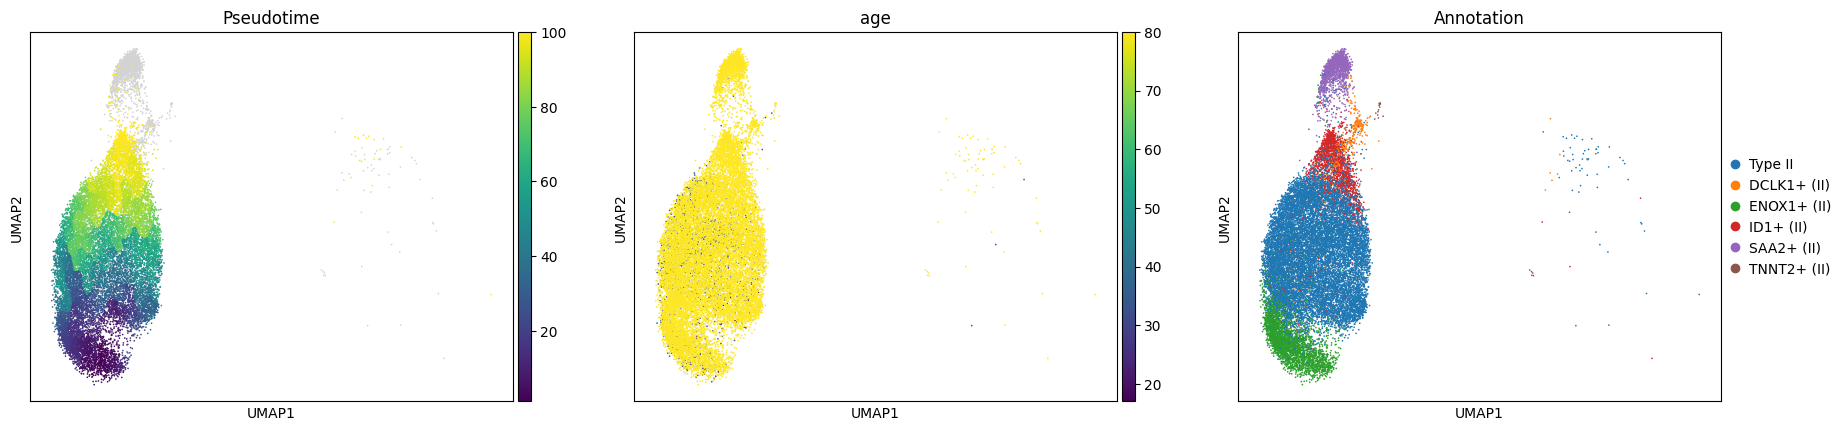

In [13]:
sc.pl.umap(rna_adata, color=['Pseudotime', 'age', 'Annotation'])

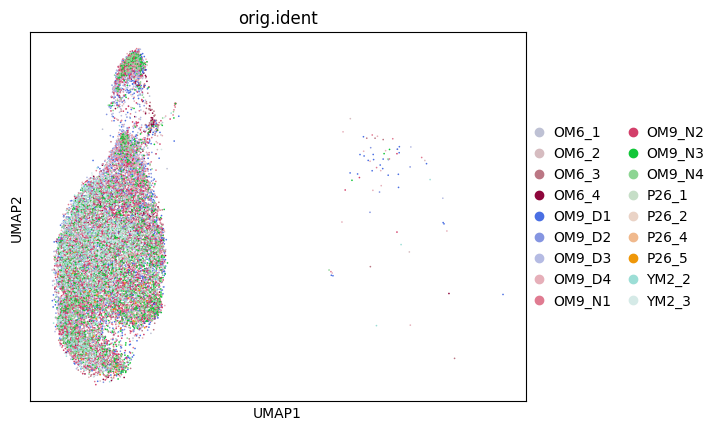

In [14]:
sc.pl.umap(rna_adata, color=['orig.ident'])

In [16]:
rna_adata.obs['sample'].value_counts()

sample
OM9    15317
OM6     3436
YM2     1989
P26      122
Name: count, dtype: int64

In [22]:
display(rna_adata.var)

,features
WASH7P,WASH7P
CICP27,CICP27
AL732372.2,AL732372.2
AL669831.3,AL669831.3
MTND2P28,MTND2P28
...,...
AC063955.1,AC063955.1
MKNK2P1,MKNK2P1
AC087072.1,AC087072.1
CDC42P2,CDC42P2


In [37]:
#write to file 
rna_adata.write_h5ad(f"{export_dir}/rna_female_type2_YM2_1_removed.h5ad")

# Analysis for ERCC-1 paper

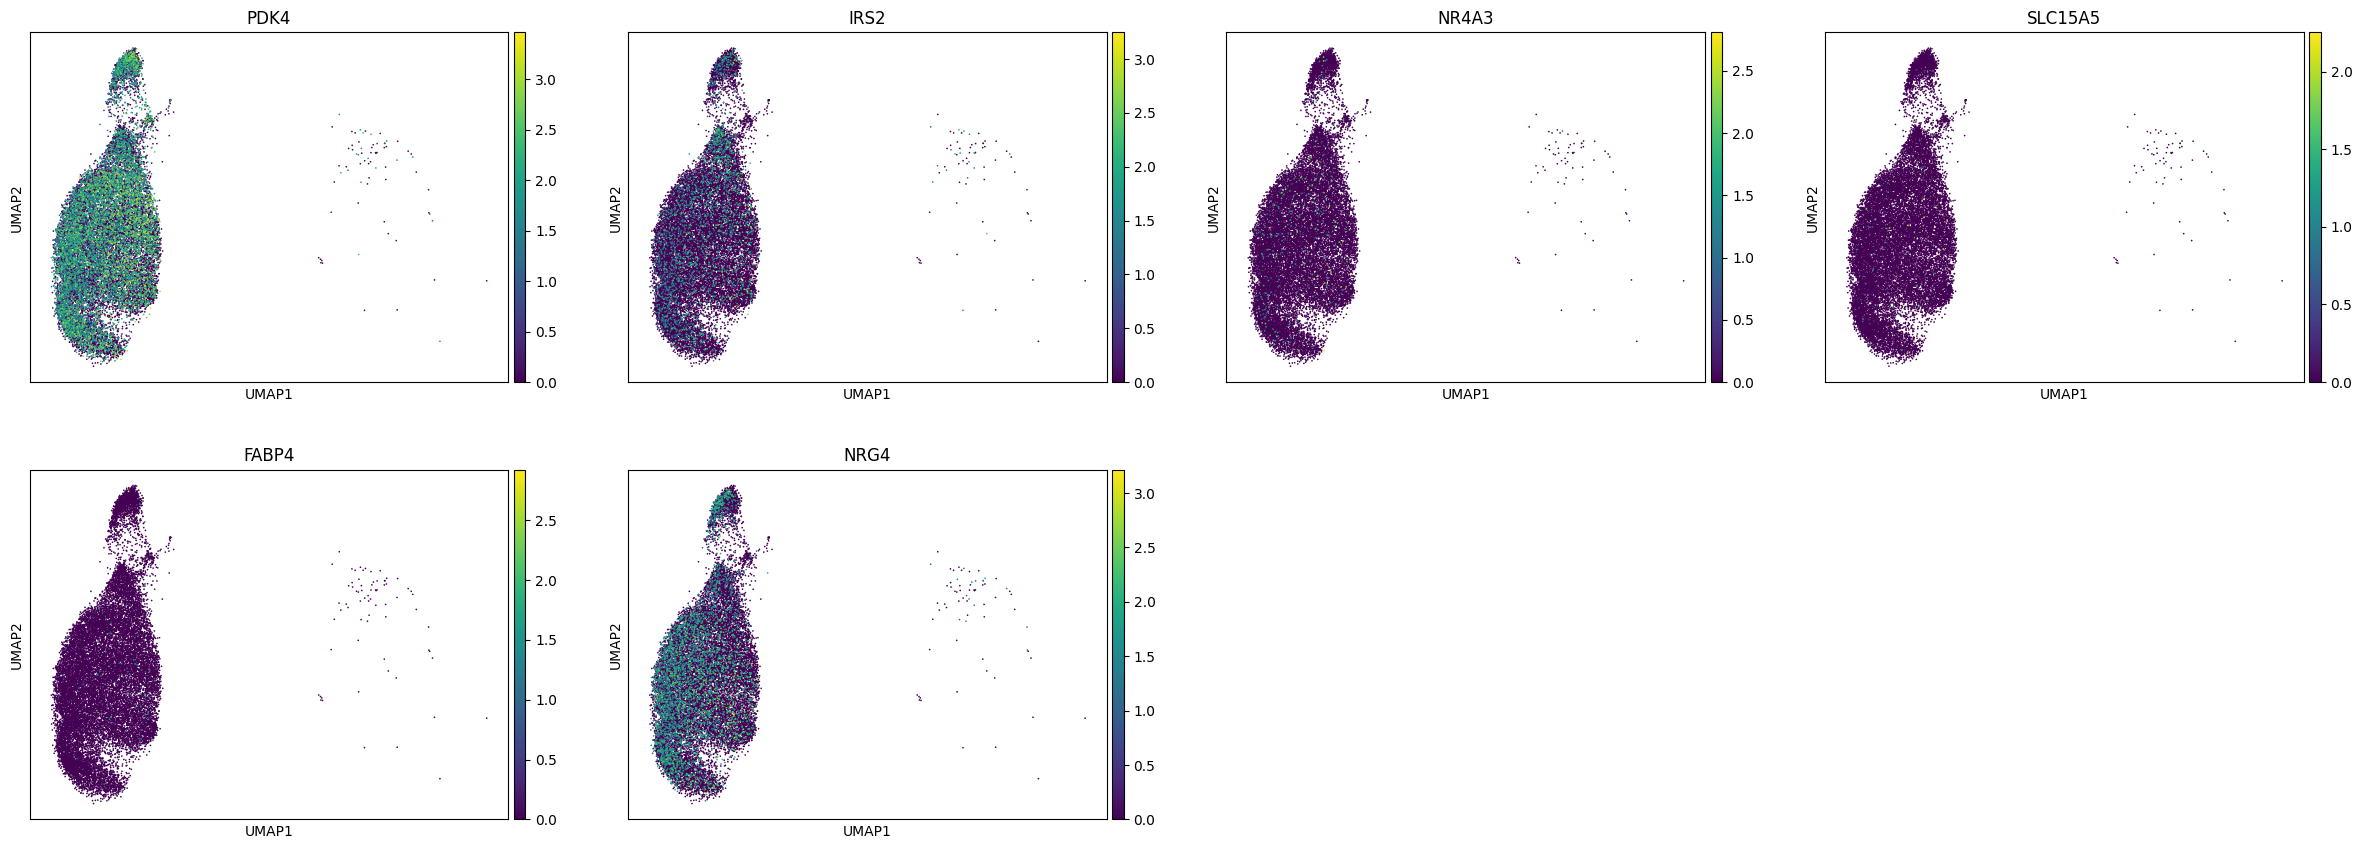

In [44]:
sc.pl.umap(rna_adata, color=['PDK4', 'IRS2', 'NR4A3', 'SLC15A5', 'FABP4', 'NRG4'])

In [47]:
rna_adata.obs['age_categorical'] = rna_adata.obs['age'].astype('category')

In [50]:
sc.pl.dotplot(rna_adata, var_names=['PDK4'], groupby='age',
              use_raw=True, standard_scale='var')

/projects/bgdb/asachan/.conda/envs/decoupler/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:2051: FutureWarning: Use obs (e.g. `k in adata.obs` or `str(adata.obs.columns.tolist())`) instead of AnnData.obs_keys, AnnData.obs_keys is deprecated and will be removed in the future.
  if group not in list(adata.obs_keys()) + [adata.obs.index.name]:


KeyError: "[Interval(35.0, 44.0, closed='right'), Interval(44.0, 53.0, closed='right'), Interval(53.0, 62.0, closed='right'), Interval(62.0, 71.0, closed='right')] not in index"

In [58]:
import scanpy as sc
import pandas as pd
from IPython.display import display

# --------------------------------------------------------------------------
# 1. Pull gene + obs columns into a tidy DataFrame
# --------------------------------------------------------------------------
gene = 'PDK4'

df_cells = sc.get.obs_df(
    rna_adata,
    keys=[gene, 'sample', 'age'],
    use_raw=True,    # set False (and pass layer='log1p' or similar) if .raw isn't what you want
)

# --------------------------------------------------------------------------
# 2. Pseudobulk: mean expression per sample (sample is the biological replicate)
# --------------------------------------------------------------------------
df_pb = (
    df_cells
    .groupby(['sample', 'age'], as_index=False)[gene]
    .mean()
)

# Quick sanity check on n_samples per age — you need >=2 per age for stats
print(df_pb.groupby('age').size().rename('n_samples'))
print(df_pb)

# Cast age to string for categorical x-axis
df_pb['age'] = df_pb['age'].astype(str)

age
17    1
34    1
80    2
Name: n_samples, dtype: int64
  sample  age      PDK4
0    OM6   80  1.652722
1    OM9   80  0.642785
2    P26   17  0.000000
3    YM2   34  0.423831


2026-04-25 21:49:00 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-25 21:49:00 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-25 21:49:00 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


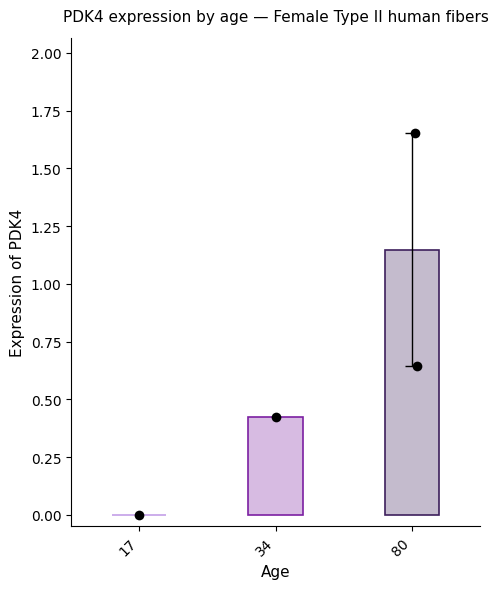

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
from IPython.display import display

gene = 'PDK4'
present_ages = sorted(df_pb['age'].unique(), key=lambda a: float(a))

palette = {
    '17': '#C4A0E7',
    '34': '#7B1FA2',
    '79': '#3D1F5C',
    '80': '#3D1F5C',
}
palette = {a: palette.get(a, '#999999') for a in present_ages}

fig, ax = plt.subplots(figsize=(5, 6))   # match violin-box aspect

# group means + SEM
bar_means = df_pb.groupby('age')[gene].mean().reindex(present_ages)
bar_sems  = df_pb.groupby('age')[gene].sem().reindex(present_ages)

x_pos = np.arange(len(present_ages))

# Translucent face + full-alpha edge — same idiom as plot_violin_box_combo
face_colors = [mcolors.to_rgba(palette[a], alpha=0.3) for a in present_ages]
edge_colors = [palette[a] for a in present_ages]

ax.bar(
    x_pos, bar_means.values,
    yerr=bar_sems.values,
    color=face_colors,
    edgecolor=edge_colors,
    linewidth=1.2,
    width=0.4,
    capsize=5,
    error_kw=dict(elinewidth=1.0, ecolor='black'),
)

# Black sample dots
sns.stripplot(
    data=df_pb, x='age', y=gene, order=present_ages,
    color='black', size=7, jitter=0.06,
    ax=ax,
)

# Axes
ax.set_xticks(x_pos)
ax.set_xticklabels(present_ages, rotation=45, ha='right')
ax.set_ylabel(f'Expression of {gene}', fontsize=11)
ax.set_xlabel('Age', fontsize=11)
ax.set_title(f'{gene} expression by age — Female Type II human fibers',
             fontsize=11, pad=12)
ax.set_ylim(-0.05, max(df_pb[gene].max() * 1.25, 0.5))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_linewidth(0.8)
ax.tick_params(axis='y', width=0.8)
ax.tick_params(axis='x', width=0.8)
plt.setp(ax.get_yticklabels(), weight='normal')

fig.tight_layout()
plt.close(fig)        # <-- kills the second render
display(fig)

### get umap for atac data

In [9]:
atac_adata = sc.read_h5ad(adata_atac)
#atac_adata = atac_adata[atac_adata.obs['sample'].isin(['P26', 'YM2', 'OM2', 'OM6', 'OM9'])].copy()

In [11]:
atac_adata

AnnData object with n_obs × n_vars = 13217 × 265003
    obs: 'Sample', 'TSSEnrichment', 'ReadsInTSS', 'ReadsInPromoter', 'ReadsInBlacklist', 'PromoterRatio', 'PassQC', 'NucleosomeRatio', 'nMultiFrags', 'nMonoFrags', 'nFrags', 'nDiFrags', 'BlacklistRatio', 'orig.ident', 'sample', 'group', 'ReadsInPeaks', 'FRIP', 'fiber_class_1_anno', 'Annotation', 'UMAP_1', 'UMAP_2', 'fiber_class_anno', 'country', 'age', 'Sex'
    uns: 'Annotation_colors', 'Sample_colors', 'fiber_class_1_anno_colors'
    obsm: 'X_UMAP'

In [12]:
#subset to type 2 fibers
#atac_adata = atac_adata[atac_adata.obs['Annotation'].str.contains('II')].copy()
atac_adata.obs

,Sample,TSSEnrichment,ReadsInTSS,ReadsInPromoter,ReadsInBlacklist,PromoterRatio,PassQC,NucleosomeRatio,nMultiFrags,nMonoFrags,...,ReadsInPeaks,FRIP,fiber_class_1_anno,Annotation,UMAP_1,UMAP_2,fiber_class_anno,country,age,Sex
YM2_semitendinosus_1#20201229_snATAC_semitendinosus1_BC000269_N05,YM2_semitendinosus_1,9.085,16690,18057,672,0.139133,1,0.185744,0,54726,...,54664,0.421199,Hybrid IIx/IIa,Type II,2.439755,5.153419,Hybrid IIx/IIa,China,34,Female
YM2_semitendinosus_1#20201229_snATAC_semitendinosus1_BC000355_N04,YM2_semitendinosus_1,8.825,9408,9856,755,0.086866,1,0.177309,0,48187,...,27887,0.245783,Type IIx,Type II,2.333863,3.418253,Type IIx,China,34,Female
YM2_semitendinosus_1#20201229_snATAC_semitendinosus1_BC000363_N02,YM2_semitendinosus_1,11.886,14754,14380,392,0.127167,1,0.162872,0,48621,...,42202,0.373205,Type IIx,Type II,3.445016,6.757733,Type IIx,China,34,Female
YM2_semitendinosus_1#20201229_snATAC_semitendinosus1_BC000458_N02,YM2_semitendinosus_1,14.105,17209,16587,476,0.150846,1,0.199703,0,45828,...,48476,0.440851,Hybrid IIx/IIa,Type II,3.014956,6.396357,Hybrid IIx/IIa,China,34,Female
YM2_semitendinosus_1#20201229_snATAC_semitendinosus1_BC000978_N04,YM2_semitendinosus_1,9.078,9485,10329,725,0.095089,1,0.160017,0,46820,...,28992,0.266902,Type IIx,Type II,3.825233,3.553320,Type IIx,China,34,Female
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Human_Muscle_200929_Normal_3#Human_Muscle_200929_Normal_3_BC4846_N01,Human_Muscle_200929_Normal_3,13.201,2160,2277,42,0.280764,1,0.028666,0,3942,...,6754,0.833416,Type IIx,ID1+ (II),3.593245,-5.417366,Type IIx,China,80,Female
Human_Muscle_200929_Normal_3#Human_Muscle_200929_Normal_3_BC4840_N01,Human_Muscle_200929_Normal_3,11.059,1709,1784,36,0.220628,1,0.468046,117,2754,...,5451,0.675800,Type IIx,Type II,6.563418,1.511425,Type IIx,China,80,Female
Human_Muscle_200929_Normal_3#Human_Muscle_200929_Normal_3_BC4869_N01,Human_Muscle_200929_Normal_3,12.034,1969,2053,44,0.258499,1,0.046653,1,3794,...,6106,0.769211,Type IIa,ID1+ (II),3.193637,-2.000290,Type IIa,China,80,Female
Human_Muscle_200929_Normal_3#Human_Muscle_200929_Normal_3_BC4918_N01,Human_Muscle_200929_Normal_3,10.024,1544,1748,63,0.226660,1,0.010217,3,3817,...,5107,0.662902,Type IIx,SAA2+ (II),3.437193,-4.520675,Type IIx,China,80,Female


In [13]:
atac_adata.obs['Sample'].value_counts()

YM2_semitendinosus_1                   1901
YM2_semitendinosus_3                   1735
YM2_semitendinosus_2                   1614
OM2_Normal_2                           1148
YSM1_2_Semit1_scATAC                    772
Human_Muscle_200929_Damage_4            615
Human_Muscle_200929_Damage_3            613
YSM1_2_Semit4_scATAC                    600
Human_Muscle_200929_Normal_4            598
Human_Muscle_200929_Normal_1            570
Human_Muscle_200929_Damage_2            568
Human_Muscle_200929_Damage_1            541
Human_Muscle_200929_Normal_2            541
Human_Muscle_200929_Normal_3            529
YSM1_2_Semit2_scATAC                    373
YSM1_2_Semit3_scATAC                    256
Human_Muscle_80Year_201112_female_4     243
Name: Sample, dtype: int64

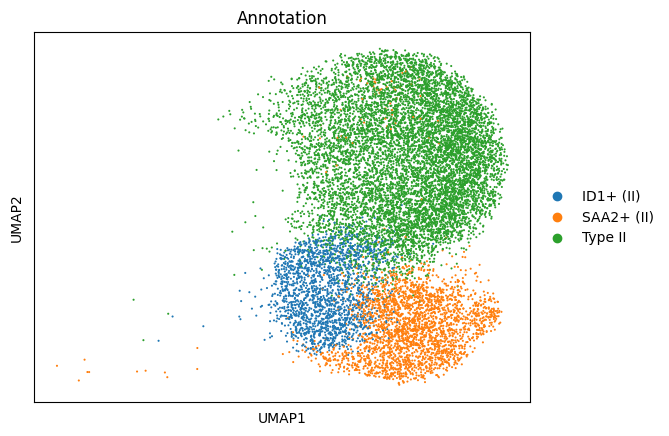

In [34]:
sc.pl.embedding(atac_adata, basis='UMAP', color=['Annotation'])

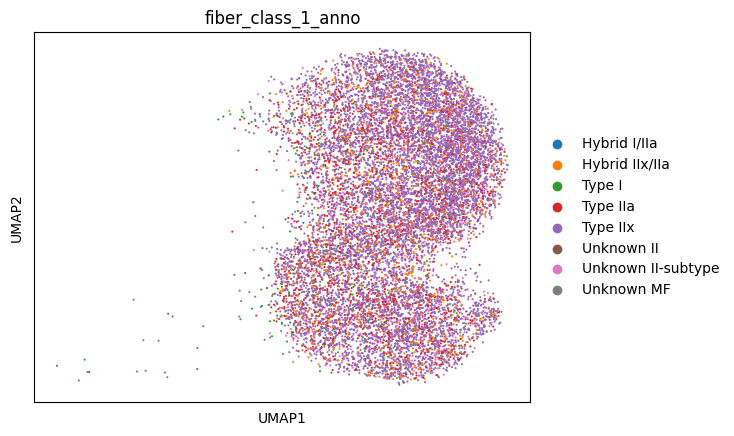

In [35]:
sc.pl.embedding(atac_adata, basis='UMAP', color=['fiber_class_1_anno'])

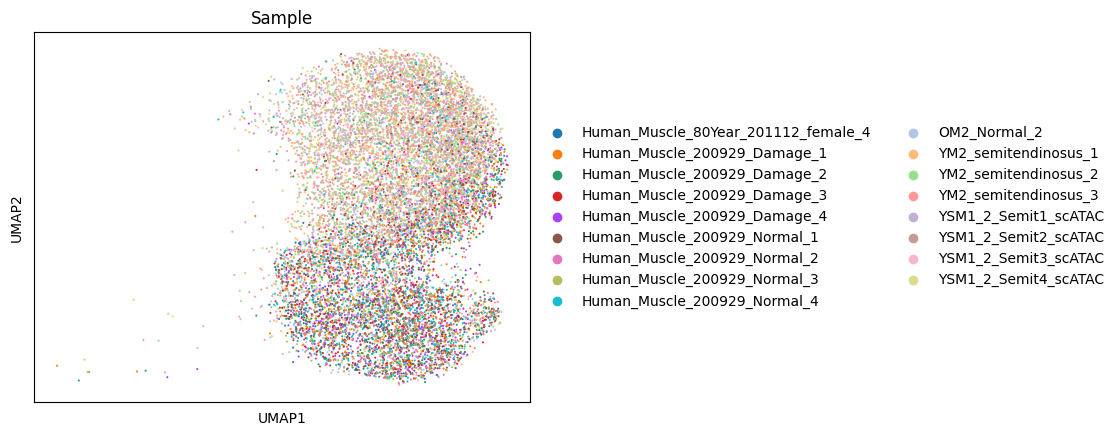

In [36]:
sc.pl.embedding(atac_adata, basis='UMAP', color=['Sample'])

In [ ]:
# write to file 
atac_adata.write_h5ad(f"{export_dir}/atac_female_type2.h5ad")


## Molecular age (pseudotime based) to sub-sample

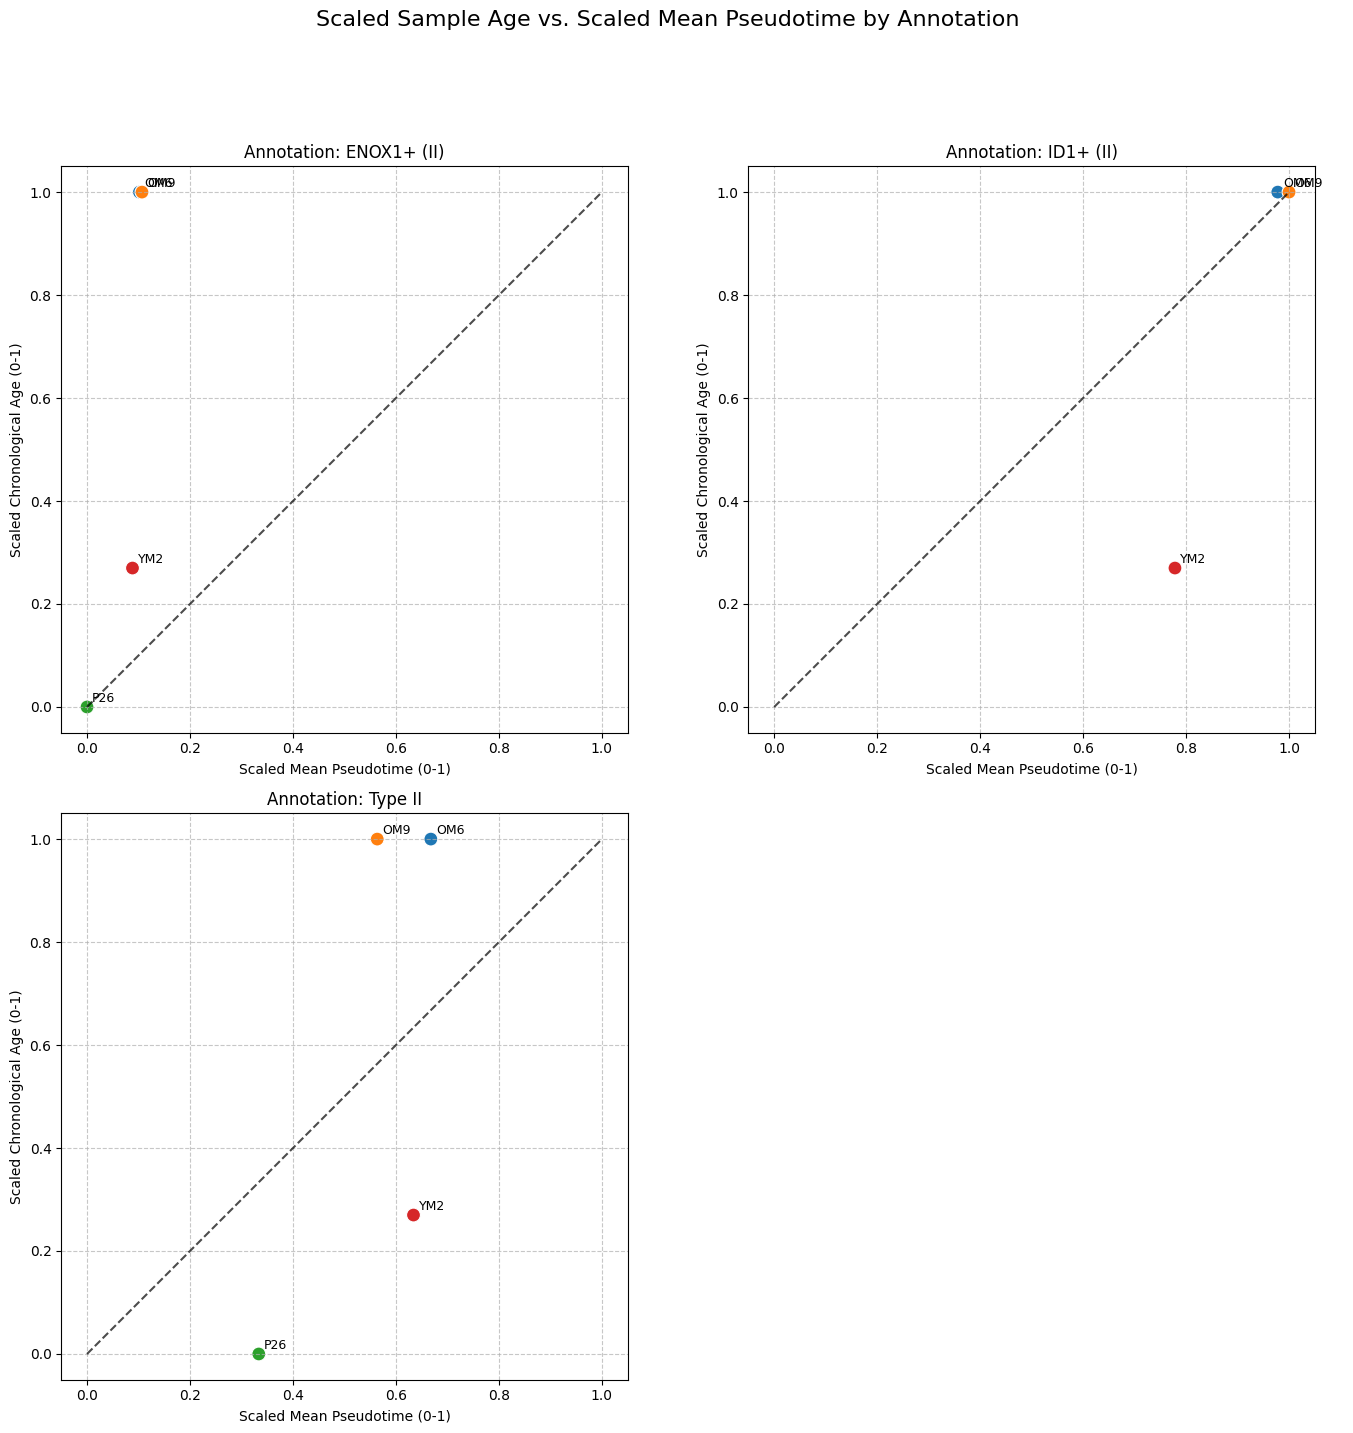

In [18]:
fig_by_annotation, summary_df_all = plot_age_vs_pseudotime_by_annotation(
    rna_adata,
    annotation_col='Annotation', # Make sure this column name is correct
    point_size=100,
    n_subplot_cols=2 # Or 1 if you only have 'Type I' and 'Type II' and want them stacked
)

# AUCell activity scoring of specific pathways

In [25]:
# load geneset of interest
geneset_dir = '/work/hdd/bgdb/asachan/datasets_proj/gene_sets'
# geneset_gmt = ["/ocean/projects/cis240075p/asachan/datasets/gene_sets/human/metabolism/GOBP_FATTY_ACID_BETA_OXIDATION.v2024.1.Hs.gmt", "/ocean/projects/cis240075p/asachan/datasets/gene_sets/human/metabolism/KEGG_CITRATE_CYCLE_TCA_CYCLE.v2024.1.Hs.gmt", "/ocean/projects/cis240075p/asachan/datasets/gene_sets/human/metabolism/KEGG_GLYCOLYSIS_GLUCONEOGENESIS.v2024.1.Hs.gmt",
#                "/ocean/projects/cis240075p/asachan/datasets/gene_sets/human/metabolism/KEGG_OXIDATIVE_PHOSPHORYLATION.v2024.1.Hs.gmt","/ocean/projects/cis240075p/asachan/datasets/gene_sets/human/metabolism/REACTOME_BRANCHED_CHAIN_AMINO_ACID_CATABOLISM.v2024.1.Hs.gmt","/ocean/projects/cis240075p/asachan/datasets/gene_sets/human/metabolism/REACTOME_GLUTAMATE_AND_GLUTAMINE_METABOLISM.v2024.1.Hs.gmt"]
# geneset_df = gmt_to_decoupler_multiple_pathways(geneset_gmt)
geneset_gmt = [os.path.join(geneset_dir, 'human/DNA_repair/GOBP_DNA_REPAIR.v2024.1.Hs.gmt'), os.path.join(geneset_dir, 'human/DNA_damage_response/GOBP_DNA_DAMAGE_RESPONSE.v2024.1.Hs.gmt'), 
               os.path.join(geneset_dir, 'human/DNA_repair/REACTOME_DNA_REPAIR.v2024.1.Hs.gmt'), os.path.join(geneset_dir, 'human/DNA_repair/HALLMARK_DNA_REPAIR.v2024.1.Hs.gmt')]
geneset_df = gmt_to_decoupler_multiple_pathways(geneset_gmt, geneset_name='source', genesymbol_name='target')
# get the number of rows in each unique geneset
geneset_size = geneset_df['source'].value_counts()
display(geneset_size)
display(geneset_df)
# custom_atrophy_pathway = ["UBB","UBC","FBXO32","TRIM63","MDM2","FBXO30","CAMK2B","TIE1","PSMA1","PSMA2","PSMA3","PSMA4","PSMA5","PSMA6","PSMA7","PSMB1","PSMB2","PSMB3","PSMB4","FBXO21","FBXO31","NEDD4","UBE2B","UBE2G1","UBE2J1","CTSL","CTSV","BNIP3","DEPP1","GABARAPL1","MAP1LC3","RETREG1","SQSTM1","CAPN1","CAPN2","ATF4","FOXO1","FOXO3A","HDAC9","RUNX1","AMPD3","CHRNA1","CDKN1A"]
# geneset_df = pd.DataFrame({'geneset': "Atrophy Pathway (PMID: 31325479)", 'genesymbol': custom_atrophy_pathway})
# geneset_df


source
GOBP_DNA_DAMAGE_RESPONSE    906
GOBP_DNA_REPAIR             615
REACTOME_DNA_REPAIR         332
HALLMARK_DNA_REPAIR         150
Name: count, dtype: int64

,source,target
0,GOBP_DNA_REPAIR,ABL1
1,GOBP_DNA_REPAIR,ABRAXAS1
2,GOBP_DNA_REPAIR,ACTB
3,GOBP_DNA_REPAIR,ACTL6A
4,GOBP_DNA_REPAIR,ACTL6B
...,...,...
1998,HALLMARK_DNA_REPAIR,VPS37B
1999,HALLMARK_DNA_REPAIR,VPS37D
2000,HALLMARK_DNA_REPAIR,XPC
2001,HALLMARK_DNA_REPAIR,ZNF707


In [26]:
%%time
decoupler.mt.aucell(
    rna_adata,
    geneset_df,
    raw=False,
    verbose=True
)

2026-04-25 21:04:28 | [INFO] aucell - Running aucell
2026-04-25 21:04:28 | [INFO] Extracted omics mat with 20864 rows (observations) and 48355 columns (features)
2026-04-25 21:04:28 | [WARNING] 7938 features of mat are empty, they will be removed
2026-04-25 21:04:29 | [WARNING] weight not found in net.columns, adding it as:
net['weight'] = 1
2026-04-25 21:04:29 | [INFO] Network has 1029 unique features and 4 unique sources
2026-04-25 21:04:29 | [INFO] aucell - calculating 4 AUCs for 40417 targets across 20864 observations, categorizing features at rank=2021


  0%|          | 0/20864 [00:00<?, ?it/s]

2026-04-25 21:05:06 | [INFO] aucell - done


CPU times: user 36.5 s, sys: 582 ms, total: 37.1 s
Wall time: 37.8 s


In [27]:
dna_damage_pathways = [
    "GOBP_DNA_REPAIR",
    "GOBP_DNA_DAMAGE_RESPONSE",
    "REACTOME_DNA_REPAIR",
    "HALLMARK_DNA_REPAIR"
]
# metabolic_pathways = [
#     "GOBP_FATTY_ACID_BETA_OXIDATION",
#     "KEGG_CITRATE_CYCLE_TCA_CYCLE",
#     "KEGG_GLYCOLYSIS_GLUCONEOGENESIS",
#     "KEGG_OXIDATIVE_PHOSPHORYLATION",
#     "REACTOME_BRANCHED_CHAIN_AMINO_ACID_CATABOLISM",
#     "REACTOME_GLUTAMATE_AND_GLUTAMINE_METABOLISM"
# ]

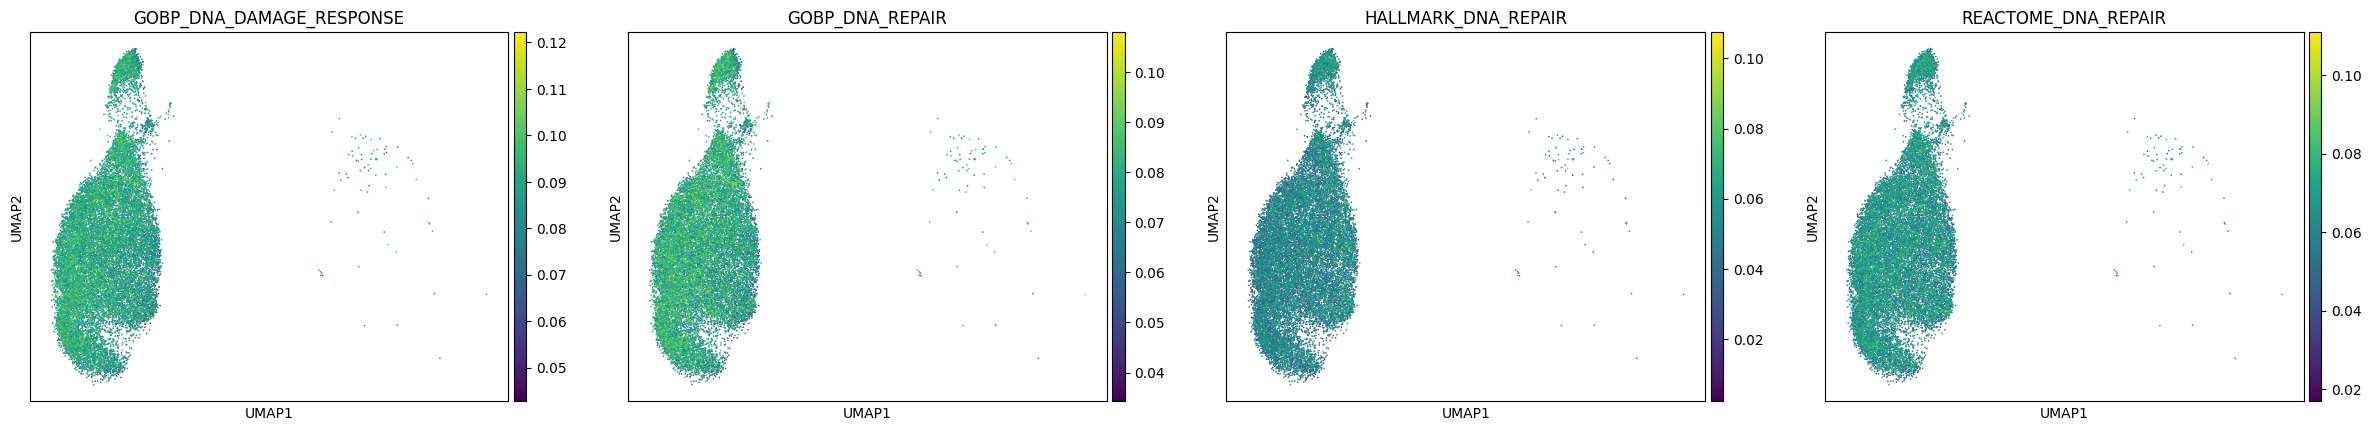

In [28]:
# Copy AUCell scores to obs so you can use them as color
aucell_df = rna_adata.obsm['score_aucell']
for col in aucell_df.columns:
    rna_adata.obs[col] = aucell_df[col].values

# Then plot on UMAP
sc.pl.umap(rna_adata, color=aucell_df.columns.tolist())

### Plot samples ordered by score to select outliers for bar-plot comparitive analysis between cohorts

In [29]:
# get a df of sample ID, sample score per cell type and age
sample_scores = rna_adata.obs[['sample','age', 'Annotation']+dna_damage_pathways].copy()
# average scores per sample and group by Annotation
sample_scores_avg = sample_scores.groupby(['sample', 'Annotation']).mean().reset_index()
sample_scores_avg.head()

,sample,Annotation,age,GOBP_DNA_REPAIR,GOBP_DNA_DAMAGE_RESPONSE,REACTOME_DNA_REPAIR,HALLMARK_DNA_REPAIR
0,OM6,Type II,80.0,0.071334,0.085245,0.057722,0.042372
1,OM6,DCLK1+ (II),80.0,0.068586,0.080905,0.058586,0.047451
2,OM6,ENOX1+ (II),80.0,0.071691,0.086169,0.058269,0.041281
3,OM6,ID1+ (II),80.0,0.071873,0.086392,0.057932,0.043319
4,OM6,SAA2+ (II),80.0,0.068196,0.081581,0.055937,0.044263


## Plots wrt age

In [30]:
# Use cell-level data directly from adata.obs
cell_level_scores_df = rna_adata.obs[['sample', 'age', 'Annotation', 'Pseudotime'] + dna_damage_pathways].copy()
# geneset_sizes_data = {
#     'KEGG_OXIDATIVE_PHOSPHORYLATION': 132,
#     'GOBP_FATTY_ACID_BETA_OXIDATION': 75,
#     'KEGG_GLYCOLYSIS_GLUCONEOGENESIS': 62,
#     'KEGG_CITRATE_CYCLE_TCA_CYCLE': 31,
#     'REACTOME_BRANCHED_CHAIN_AMINO_ACID_CATABOLISM': 21,
#     'REACTOME_GLUTAMATE_AND_GLUTAMINE_METABOLISM': 14
# }
geneset_sizes_data = {
    'GOBP_DNA_REPAIR': 615,
    'GOBP_DNA_DAMAGE_RESPONSE': 906,
    'REACTOME_DNA_REPAIR': 332,
    'HALLMARK_DNA_REPAIR': 150
}
geneset_sizes_series = pd.Series(geneset_sizes_data)

2026-04-25 21:10:42 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


/projects/bgdb/asachan/bioinfo_analysis/human_SKM_multimodal_analysis/py_scripts/utils.py:1190: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  violin = sns.violinplot(
2026-04-25 21:10:42 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-25 21:10:42 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-25 21:10:42 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-25 21:10:42 | [INFO] Using ca

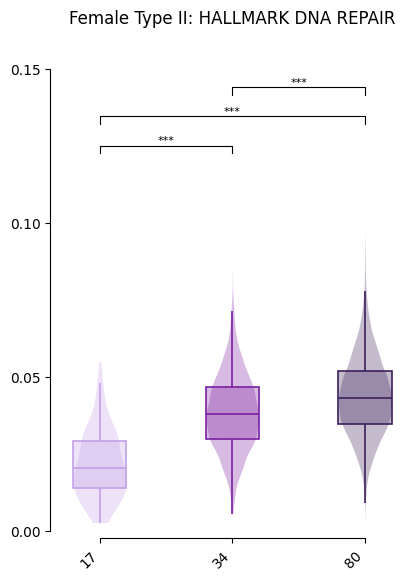

<Figure size 640x480 with 0 Axes>

In [35]:
plot_data = cell_level_scores_df.copy()
plot_data['age'] = plot_data['age'].astype(str)

custom_colors = {
    '17': '#C4A0E7',
    '34': '#7B1FA2',
    '79': '#3D1F5C',
    '80': '#3D1F5C'
}

# custom_colors = {
#     '38': '#87CEEB',  # Sky blue
#     '45': '#4682B4',  # Steel blue
#     '82': '#191970'  # Midnight blue,
# }

fig = plot_violin_box_combo(
    data=plot_data,
    x_var='age',
    y_var='HALLMARK_DNA_REPAIR',
    title='Female Type II: HALLMARK DNA REPAIR',
    x_ticks=['17','34','80'],
    palette=custom_colors,
    rotation=45,
    show_scatter=False
)

# Display the plot
from IPython.display import display
display(fig)
# save as pdf 
#fig.savefig('/ocean/projects/cis240075p/asachan/datasets/senescence_datasets/mouse_liver/figures/cellage_scores.pdf', bbox_inches='tight')

## Plots wrt pseudotime

2026-04-25 21:09:30 | [INFO] Animation.save using <class 'matplotlib.animation.PillowWriter'>


⚠ FFmpeg not found - will use GIF format instead

Starting animation creation...
Figure created with 1 animated lines
Creating animation with 200 frames at 30 fps...
Saving as GIF to pathway_animation.gif...
✓ GIF saved successfully!


/projects/bgdb/asachan/bioinfo_analysis/human_SKM_multimodal_analysis/py_scripts/pathway_animation.gif


Animation saved! Click the link above to download.

Animation creation complete!


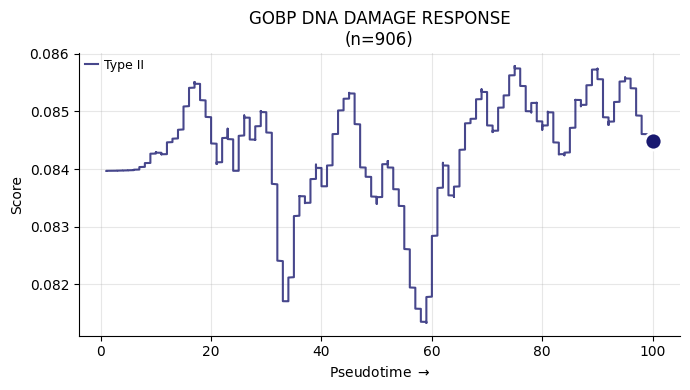

In [34]:
# ====== USAGE ======
plot_colors = {'Type II': '#191970'}
legend_labels = {'Type II': 'Type II'}

# First, let's check if ffmpeg is available
import subprocess
try:
    result = subprocess.run(['ffmpeg', '-version'], 
                          capture_output=True, text=True, timeout=5)
    print("✓ FFmpeg is installed")
    use_gif_format = False
except:
    print("⚠ FFmpeg not found - will use GIF format instead")
    use_gif_format = True

print()


# Your list of score columns
score_cols_to_plot = ['GOBP_DNA_DAMAGE_RESPONSE']

# Create animation
anim_result = create_animated_pathway_plot(
    df_cell_level=cell_level_scores_df,
    score_cols=score_cols_to_plot,
    pseudotime_key='Pseudotime',
    group_by_key='Annotation',
    smoothing_method='gaussian',
    smoothing_strength=120.0,  # Smoother lines
    geneset_sizes=geneset_sizes_series,
    groups_to_plot=['Type II'],
    colors_dict=plot_colors,
    legend_labels_map=legend_labels,
    n_subplot_cols=1,
    figsize_per_subplot=(7, 4),
    nframes=200,  # More frames = smoother
    fps=30,
    dot_size=150,
    output_file='pathway_animation.mp4',
    use_gif=use_gif_format  # Will auto-detect
)

print("\n" + "=" * 60)
print("Animation creation complete!")
print("=" * 60)

In [ ]:
# # Colors for 'Type I' and 'Type II'
# plot_colors = {'Type I': '#F08080', 'Type II': '#191970'}
# legend_labels = {'Type I': 'Type I', 'Type II': 'Type II'}

# plot_multi_smoothed_lines_from_df(
#     df_cell_level=cell_level_scores_df,
#     score_cols=score_cols_to_plot,
#     pseudotime_key='Pseudotime',
#     group_by_key='Annotation',
#     smoothing_method='gaussian',          # Specify method
#     smoothing_strength=70.0,             # Fraction for LOWESS (e.g., 0.05 to 0.2)
#     geneset_sizes=geneset_sizes_series,
#     groups_to_plot=['Type I', 'Type II'],
#     colors_dict=plot_colors,
#     legend_labels_map=legend_labels,
#     n_subplot_cols=2,
#     figsize_per_subplot=(7, 4),
#     common_xlabel=r"Pseudotime $\rightarrow$",
#     common_ylabel="Score",
#     common_ylim=None, common_xticks_list=None, common_yticks_list=None,
#     common_legend_loc=(0.02, 0.85), common_line_kwargs={'linewidth': 1.0},
#     main_figure_title=None,
#     debug_prints_for_subp_plot_func=False
# )


# ATAC data load

In [15]:
import anndata as ad
import scanpy as sc
import pandas as pd
import numpy as np
from scipy.io import mmread
from scipy.sparse import csr_matrix
import os

In [16]:
export_dir = "/projects/bgdb/asachan/datasets/SKM_ageing_human/atac_objects/atac_fiber"

# ═══════════════════════════════════════════
# A. Build ATAC AnnData
# ═══════════════════════════════════════════
counts = csr_matrix(mmread(f"{export_dir}/atac_counts.mtx").T)  # peaks×cells → cells×peaks
peaks  = open(f"{export_dir}/peaks.tsv").read().strip().split("\n")
bcs    = open(f"{export_dir}/barcodes.tsv").read().strip().split("\n")
umap_emb = pd.read_csv(f"{export_dir}/embedding_UMAP.tsv", sep="\t", index_col=0)

adata_atac = ad.AnnData(X=counts, obs=pd.DataFrame(index=bcs), var=pd.DataFrame(index=peaks))

# Metadata
meta = pd.read_csv(f"{export_dir}/metadata.csv", index_col=0)
adata_atac.obs = meta.reindex(adata_atac.obs_names)

# Embeddings
for f in os.listdir(export_dir):
    if f.startswith("embedding_") and f.endswith(".tsv"):
        name = f.replace("embedding_", "").replace(".tsv", "")
        emb = pd.read_csv(f"{export_dir}/{f}", sep="\t", index_col=0)
        adata_atac.obsm[f"X_{name}"] = emb.reindex(adata_atac.obs_names).values
        print(f"  Added X_{name}: {adata_atac.obsm[f'X_{name}'].shape}")

adata_atac.write(f"{export_dir}/atac_peaks.h5ad")
print(f"ATAC AnnData: {adata_atac.shape}")

  Added X_UMAP: (65380, 2)
ATAC AnnData: (65380, 265003)


In [14]:
adata_atac = sc.read_h5ad(f"{export_dir}/atac_peaks.h5ad")

In [17]:
## subset to type2 female fibers
adata_atac = adata_atac[adata_atac.obs['Annotation'].str.contains('II')].copy()
adata_atac.obs


,Sample,TSSEnrichment,ReadsInTSS,ReadsInPromoter,ReadsInBlacklist,PromoterRatio,PassQC,NucleosomeRatio,nMultiFrags,nMonoFrags,...,ReadsInPeaks,FRIP,fiber_class_1_anno,Annotation,UMAP_1,UMAP_2,fiber_class_anno,country,age,Sex
Human_Muscle_210209_Normal_3#Human_Muscle_210209_Normal_3_BC04672_N02,Human_Muscle_210209_Normal_3,8.543,5548,5963,311,0.106349,1,0.651936,2826,16971,...,17323,0.309063,Type IIx,SAA2+ (II),4.414549,-7.525551,Type IIx,China,79,Male
Human_Muscle_210209_Normal_3#Human_Muscle_210209_Normal_3_BC06312_N03,Human_Muscle_210209_Normal_3,12.623,10276,11016,347,0.198408,1,0.481140,1772,18743,...,28162,0.507277,Hybrid IIx/IIa,SAA2+ (II),3.379762,-5.507559,Hybrid IIx/IIa,China,79,Male
Human_Muscle_210209_Normal_3#Human_Muscle_210209_Normal_3_BC05992_N03,Human_Muscle_210209_Normal_3,13.030,10456,10636,323,0.203685,1,0.500862,2148,17396,...,32705,0.626341,Unknown II-subtype,SAA2+ (II),5.594536,-6.771801,Unknown II-subtype,China,79,Male
Human_Muscle_210209_Normal_3#Human_Muscle_210209_Normal_3_BC04567_N02,Human_Muscle_210209_Normal_3,8.262,5019,5350,308,0.102644,1,0.328355,564,19619,...,14483,0.277931,Type IIa,ID1+ (II),1.825466,-4.546646,Type IIa,China,79,Male
Human_Muscle_210209_Normal_3#Human_Muscle_210209_Normal_3_BC06345_N03,Human_Muscle_210209_Normal_3,14.850,11286,11596,267,0.237535,1,0.463720,1869,16676,...,30708,0.629056,Type IIx,SAA2+ (II),4.113221,-7.013335,Type IIx,China,79,Male
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Human_Muscle_200929_Normal_3#Human_Muscle_200929_Normal_3_BC4846_N01,Human_Muscle_200929_Normal_3,13.201,2160,2277,42,0.280764,1,0.028666,0,3942,...,6754,0.833416,Type IIx,ID1+ (II),3.593245,-5.417366,Type IIx,China,80,Female
Human_Muscle_200929_Normal_3#Human_Muscle_200929_Normal_3_BC4840_N01,Human_Muscle_200929_Normal_3,11.059,1709,1784,36,0.220628,1,0.468046,117,2754,...,5451,0.675800,Type IIx,Type II,6.563418,1.511425,Type IIx,China,80,Female
Human_Muscle_200929_Normal_3#Human_Muscle_200929_Normal_3_BC4869_N01,Human_Muscle_200929_Normal_3,12.034,1969,2053,44,0.258499,1,0.046653,1,3794,...,6106,0.769211,Type IIa,ID1+ (II),3.193637,-2.000290,Type IIa,China,80,Female
Human_Muscle_200929_Normal_3#Human_Muscle_200929_Normal_3_BC4918_N01,Human_Muscle_200929_Normal_3,10.024,1544,1748,63,0.226660,1,0.010217,3,3817,...,5107,0.662902,Type IIx,SAA2+ (II),3.437193,-4.520675,Type IIx,China,80,Female


In [21]:
adata_atac_sex = adata_atac[adata_atac.obs['Sex'].isin(['Female'])].copy()

In [24]:
# remove P21 and OM3
adata_atac = adata_atac_sex[adata_atac_sex.obs['sample'] != 'P21'].copy()
adata_atac = adata_atac[adata_atac.obs['sample'] != 'OM3'].copy()

In [25]:
adata_atac.obs['sample'].value_counts()

YM2    5250
OM9    4575
P26    2001
OM2    1148
OM6     243
Name: sample, dtype: int64

In [28]:
adata_atac

AnnData object with n_obs × n_vars = 13217 × 265003
    obs: 'Sample', 'TSSEnrichment', 'ReadsInTSS', 'ReadsInPromoter', 'ReadsInBlacklist', 'PromoterRatio', 'PassQC', 'NucleosomeRatio', 'nMultiFrags', 'nMonoFrags', 'nFrags', 'nDiFrags', 'BlacklistRatio', 'orig.ident', 'sample', 'group', 'ReadsInPeaks', 'FRIP', 'fiber_class_1_anno', 'Annotation', 'UMAP_1', 'UMAP_2', 'fiber_class_anno', 'country', 'age', 'Sex'
    obsm: 'X_UMAP'

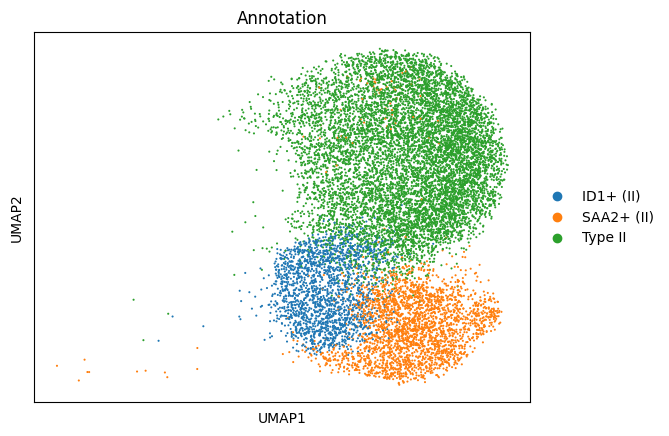

In [31]:
sc.pl.embedding(adata_atac, basis='UMAP', color=['Annotation'])

In [26]:
# write to file
adata_atac.write_h5ad(f"{export_dir}/atac_female_type2.h5ad")

In [7]:
# ═══════════════════════════════════════════
# B. Barcode harmonization
# ═══════════════════════════════════════════
# ArchR barcodes: "sampleName#ACGTACGT-1"
# 10x RNA barcodes: "ACGTACGT-1" or "sampleName_ACGTACGT-1"
# Check format and strip/adjust as needed:
print("ATAC barcodes:", adata_atac.obs_names[:3].tolist())
adata_rna = sc.read_h5ad("/projects/bgdb/asachan/datasets/SKM_ageing_human/rna_objects/type2fibers_female_downsampled_aucell.h5ad")
print("RNA barcodes:", adata_rna.obs_names[:3].tolist())

# Common fix for ArchR: strip "sampleName#" prefix
# adata_atac.obs_names = [bc.split("#")[1] if "#" in bc else bc for bc in adata_atac.obs_names]

# Or if RNA has sample prefixes: "F7_KO_ACGTACGT-1"
# you may need to build a mapping between the two naming conventions

common = adata_rna.obs_names.intersection(adata_atac.obs_names)
print(f"Shared barcodes: {len(common)} / RNA: {len(adata_rna)} / ATAC: {len(adata_atac)}")

ATAC barcodes: ['Human_Muscle_210209_Normal_3#Human_Muscle_210209_Normal_3_BC04139_N02', 'Human_Muscle_210209_Normal_3#Human_Muscle_210209_Normal_3_BC01476_N01', 'Human_Muscle_210209_Normal_3#Human_Muscle_210209_Normal_3_BC04672_N02']
RNA barcodes: ['CELL3027_N1_1_1_2_1_1', 'CELL142_N3_1_1_2_1_1', 'CELL1008_N1_1_1_2_1_1']
Shared barcodes: 0 / RNA: 8486 / ATAC: 65380


# MultiVI

In [6]:
atac_adata = sc.read_h5ad(f"{export_dir}/atac_female_type2_noP21.h5ad")
rna_adata = sc.read_h5ad(f"{export_dir}/rna_female_type2_noP21.h5ad")

In [19]:
all_cells = sc.read_h5ad("/projects/bgdb/asachan/datasets/SKM_ageing_human/rna_objects/filtered_all_cell_types.h5ad")

In [20]:
all_cells

AnnData object with n_obs × n_vars = 172396 × 48355
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'percent.mt', 'age', 'tech', 'Sex', 'Country', 'age_pop', 'Annotation'
    obsm: 'UMAP_1st', 'X_pca', 'X_pca_harmony', 'X_umap'

In [21]:
all_cells.X = all_cells.raw.X.copy()
display(all_cells.raw.X.min(), all_cells.raw.X.max())

0.0

8.778708

In [8]:
rna_adata

AnnData object with n_obs × n_vars = 23603 × 48355
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'percent.mt', 'age', 'tech', 'Sex', 'Country', 'age_pop', 'Annotation', 'Pseudotime', 'Pseudotime_typeI', 'Pseudotime_typeII', 'GOBP_DNA_DAMAGE_RESPONSE', 'GOBP_DNA_REPAIR', 'HALLMARK_DNA_REPAIR', 'REACTOME_DNA_REPAIR'
    var: 'features'
    uns: 'Final_annotation2_colors', 'Final_annotation3_colors', 'Final_annotation4_colors', 'Final_annotation_colors', 'age_pop_colors', 'anno_0713_colors', 'anno_0715_colors', 'fiber_class_V1_colors', 'integrated_snn_res.0.8_colors', 'integrated_snn_res.2.5_colors', 'integrated_snn_res.2_colors', 'integrated_snn_res.3_colors', 'integrated_snn_res.7_colors', 'rank_genes_groups'
    obsm: 'X_umap', 'score_aucell'

In [7]:
display(rna_adata.X.min(), rna_adata.X.max())

0.0

4.331152716932476

In [9]:
# load raw counts from .raw.X
rna_adata.X = rna_adata.raw.X.copy()
display(rna_adata.X.min(), rna_adata.X.max())


0.0

4.331152716932476

In [ ]:
# MultiVI needs raw counts in .X for both modalities
# RNA: integer counts (not log-normalized)
# ATAC: integer/binary peak counts (already raw from ArchR)

# If RNA .X is normalized, swap in raw counts:
# adata_rna.X = adata_rna.layers["counts"].copy()
import mudata as md

mdata = md.MuData({"rna": adata_rna, "atac": adata_atac})
print(mdata)

In [ ]:
# ═══════════════════════════════════════════
# D. MultiVI
# ═══════════════════════════════════════════
import scvi

scvi.model.MULTIVI.setup_mudata(
    mdata,
    rna_layer=None,           # None = use .X
    atac_layer=None,
    batch_key="batch",        # adjust to your batch column, or remove
    modalities={
        "rna_layer": "rna",
        "atac_layer": "atac",
    },
)

model = scvi.model.MULTIVI(mdata)
model.train()

# Joint latent space
mdata.obsm["X_MultiVI"] = model.get_latent_representation()

# Imputed modalities
# mdata.obsm["atac_imputed"] = model.get_accessibility_estimates()
# mdata.obsm["rna_imputed"] = model.get_normalized_expression()

mdata.write("multiome_multivi.h5mu")
print("Done!")